In [1]:
from visual_automata.fa.dfa import VisualDFA

dfa=VisualDFA(
    states={"q0","q1","q_err"},
    input_symbols={"[a-z]", "other"},
    transitions={
      "q0":{"[a-z]":"q1","other":"q_err"},
      "q1":{"[a-z]":"q1","other":"q_err"},
      "q_err":{"[a-z]":"q_err","other":"q_err"}
    },
    initial_state="q0",
    final_states={"q1"},
)

c:\Users\rajde\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\rajde\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


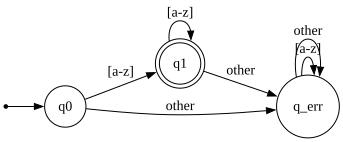

In [2]:
dfa.show_diagram()

In [3]:
def evaluate_word(word):
    if not word: return "Not Accepted"
    current_state="q0"
    transitions=dfa.transitions
    for char in word:
        symbol="[a-z]" if char.islower() and char.isalpha() else "other"
        current_state=transitions[current_state][symbol]

    return "Accepted" if current_state in dfa.final_states else "Not Accepted"

test_strings = ["cat", "dog", "a", "zebra","dog1", "1dog", "DogHouse","Dog_house", " cats"]
for s in test_strings:
    print(f"'{s}':{evaluate_word(s)}")

'cat':Accepted
'dog':Accepted
'a':Accepted
'zebra':Accepted
'dog1':Not Accepted
'1dog':Not Accepted
'DogHouse':Not Accepted
'Dog_house':Not Accepted
' cats':Not Accepted


### Part - 2

In [4]:
with open("brown_nouns.txt", "r") as file:
    corpus = [word.strip().lower() for word in file if word.strip()]

# Remove duplicates while preserving order
corpus = list(dict.fromkeys(corpus))

print("Number of words:", len(corpus))
print(corpus[:20])

Number of words: 17892
['investigation', 'primary', 'election', 'evidence', 'irregularities', 'place', 'jury', 'presentments', 'charge', 'praise', 'thanks', 'manner', 'term', 'reports', 'handful', 'interest', 'number', 'voters', 'size', 'city']


In [5]:
# (current_state, input) -> (next_state, output)
EPSILON = ""

transitions = {
    #normal chars
    ("q0", "letter"): ("qN", "SAME"),

    # deefault root
    ("qN", "letter"): ("qN", "SAME"),

    # last -y detect
    ("qN", "y"): ("qY", "y"),

    # s/z/x detect
    ("qN", "s"): ("qSZx", "s"),
    ("qN", "z"): ("qSZx", "z"),
    ("qN", "x"): ("qSZx", "x"),

    # detect sh/ch
    ("qN", "c"): ("qC", "c"),
    ("qC", "h"): ("qCH", "h"),

    ("qN", "s"): ("qS", "s"),
    ("qS", "h"): ("qSH", "h"),

    # y - ies
    ("qY", "i"): ("qYI", EPSILON),
    ("qYI", "e"): ("qYIE", EPSILON),
    ("qYIE", "s"): ("qPL", EPSILON),

    # s, x, x
    ("qSZx", "e"): ("qE", EPSILON),
    ("qE", "s"): ("qPL", EPSILON),

    # -ch or -sh
    ("qCH", "e"): ("qCHE", EPSILON),
    ("qCHE", "s"): ("qPL", EPSILON),

    ("qSH", "e"): ("qSHE", EPSILON),
    ("qSHE", "s"): ("qPL", EPSILON),

    # default
    ("qN", "s"): ("qPL", EPSILON),
}

In [6]:
ALPHABET = set("abcdefghijklmnopqrstuvwxyz")

def get_symbol(char):
    return char if char in ALPHABET else None

In [7]:
expanded_transitions = {}

for (state, symbol), (next_state, output) in transitions.items():
    if symbol == "letter":
        for char in ALPHABET:
            expanded_transitions[(state, char)] = (next_state, char)

    else:
        expanded_transitions[(state, symbol)] = (next_state, output)

In [8]:
SINGULAR_STATES = {
    "qN",
    "qY",
    "qSZx",
    "qCH",
    "qSH"
}

PLURAL_STATE = "qPL"

In [9]:
def run_fst(word):
    state = "q0"
    output = []

    for char in word:
        transition = expanded_transitions.get((state, char))

        if transition is None:
            return "Invalid Word"

        next_state, out = transition

        if out != EPSILON:
            output.append(out)

        state = next_state
        # input ends

    if state in SINGULAR_STATES:
        return "".join(output) + "+N+SG"

    if state == PLURAL_STATE:
        return "".join(output) + "+N+PL"

    return "Invalid Word"

In [10]:
test_words = [
    "fox",
    "foxes",
    "watch",
    "watches",
    "try",
    "tries",
    "bag",
    "bags",
    "foxs"
]

for word in test_words:
    print(f"{word} = {run_fst(word)}")

fox = fox+N+SG
foxes = fox+N+PL
watch = watch+N+SG
watches = watch+N+PL
try = try+N+SG
tries = trie+N+PL
bag = bag+N+SG
bags = bag+N+PL
foxs = Invalid Word


In [11]:
# Read Brown noun corpus
with open("brown_nouns.txt", "r", encoding="utf-8") as file:
    nouns = {
        line.strip().lower()
        for line in file
        if line.strip()
    }

# Determine which pluralization rule applies

def get_rule(root):
    # E insertion
    # e.g.
    # fox  -> foxes
    # watch -> watches
    # box -> boxes
    # dish -> dishes

    if root.endswith(("s", "z", "x", "ch", "sh")):
        return "E"

    # Y replacement
    # e.g.
    # try -> tries
    # city -> cities

    if (
        root.endswith("y")
        and len(root) > 1
        and root[-2] not in "aeiou"
    ):
        return "Y"

    # S addition
    # e.g.
    # bag -> bags
    # dog -> dogs

    return "S"


# FST Analyzer
def analyze_word(word):
    word = word.strip().lower()

    # Empty input
    if not word:
        return "Invalid Word"

    # E INSERTION
    #
    # foxes -> fox
    # watches -> watch
    # boxes -> box
    # dishes -> dish
    #
    if word.endswith("es"):
        root = word[:-2]

        if root in nouns and get_rule(root) == "E":
            return f"{root}+N+PL"


    # Y REPLACEMENT
    #
    # tries -> try
    # cities -> city
    #
    # Remove "ies" and restore "y".

    if word.endswith("ies"):
        root = word[:-3] + "y"

        if root in nouns and get_rule(root) == "Y":
            return f"{root}+N+PL"


    # S ADDITION
    #
    # bags -> bag
    # dogs -> dog
    #
    # Remove the final s.

    if word.endswith("s"):
        root = word[:-1]

        if root in nouns and get_rule(root) == "S":
            return f"{root}+N+PL"


    # SINGULAR
    if word in nouns:
        return f"{word}+N+SG"


    # INVALID
    return "Invalid Word"


# Test cases
test_strings = [
    "fox",
    "foxes",
    "foxs",

    "watch",
    "watches",

    "try",
    "tries",

    "bag",
    "bags"
]


for word in test_strings:
    print(f"{word} = {analyze_word(word)}")

fox = fox+N+SG
foxes = fox+N+PL
foxs = Invalid Word
watch = watch+N+SG
watches = watch+N+PL
try = try+N+SG
tries = try+N+PL
bag = bag+N+SG
bags = bag+N+PL
